# 02 — Conditioning Preview
Visualize source images alongside their Canny and depth conditioning outputs, and inspect the registry.

In [2]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

REPO_ROOT = Path("../")
REGISTRY_PATH = REPO_ROOT / "data/conditioning/registry/conditioning_registry.json"

with open(REGISTRY_PATH) as f:
    registry = json.load(f)

print(f"Registry loaded: {len(registry)} entries")

Registry loaded: 71 entries


## 3 Random Images — Source / Canny / Depth

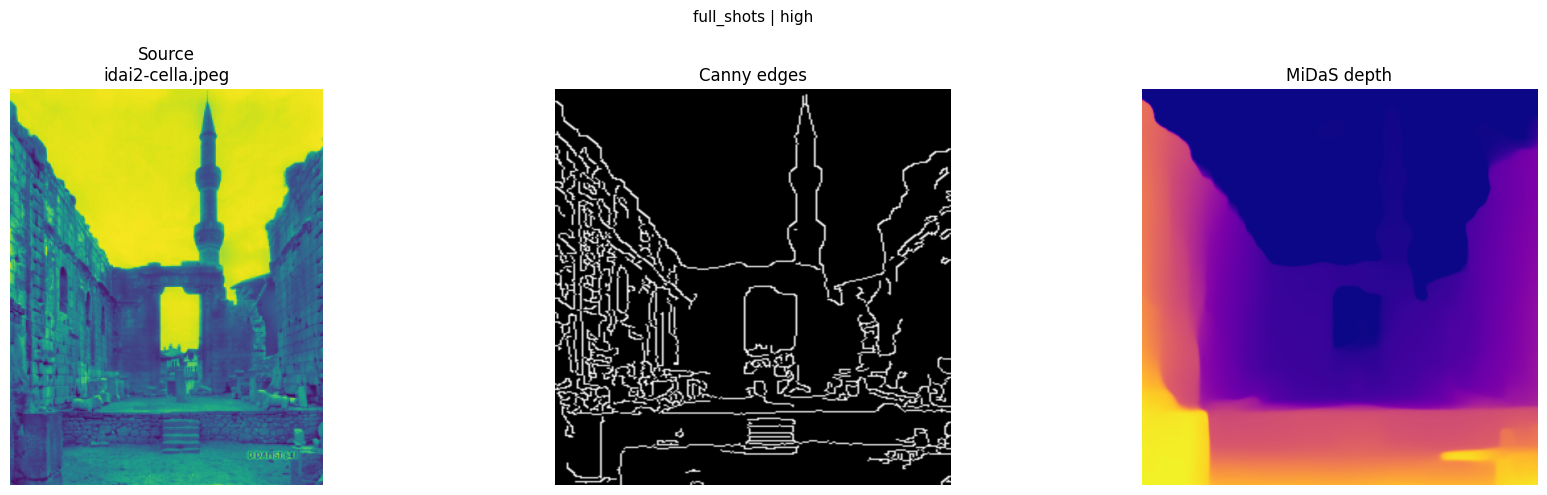

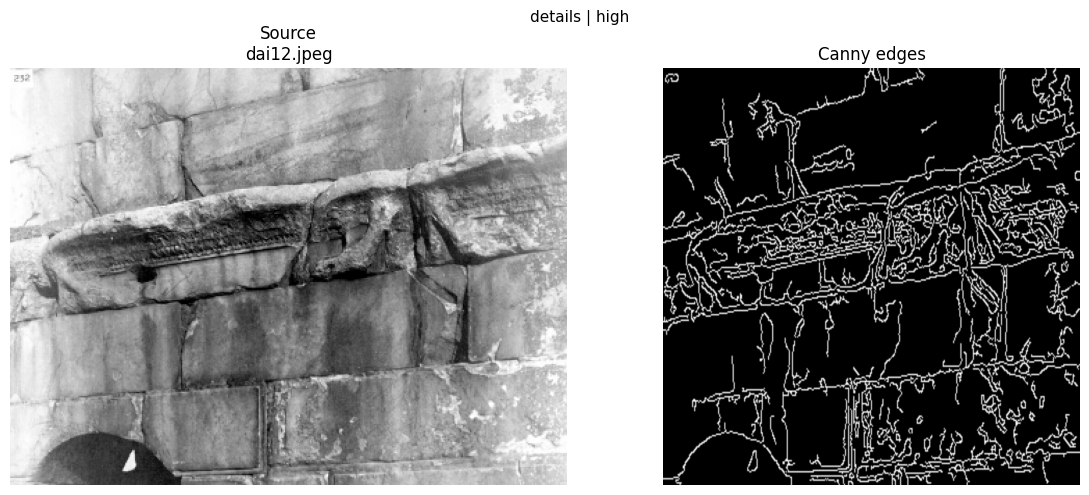

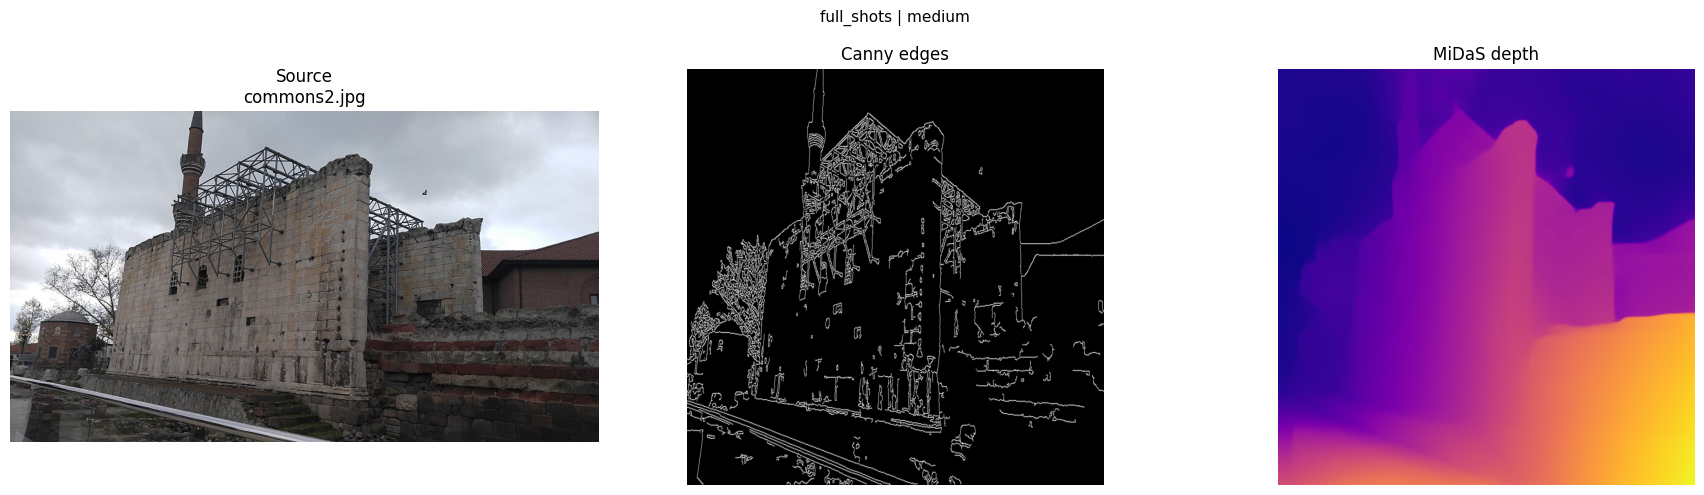

In [3]:
# Pick 3 random entries that have at least a canny output
candidates = [e for e in registry if e["canny_path"] is not None]
samples = random.sample(candidates, min(3, len(candidates)))

for entry in samples:
    source = Path(entry["source_path"])
    canny  = Path(entry["canny_path"]) if entry["canny_path"] else None
    depth  = Path(entry["depth_path"]) if entry["depth_path"] else None

    n_cols = 1 + (1 if canny else 0) + (1 if depth else 0)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5))
    if n_cols == 1:
        axes = [axes]

    ax_idx = 0
    axes[ax_idx].imshow(mpimg.imread(source))
    axes[ax_idx].set_title(f"Source\n{entry['source_filename']}")
    axes[ax_idx].axis("off")
    ax_idx += 1

    if canny:
        axes[ax_idx].imshow(mpimg.imread(canny), cmap="gray")
        axes[ax_idx].set_title("Canny edges")
        axes[ax_idx].axis("off")
        ax_idx += 1

    if depth:
        axes[ax_idx].imshow(mpimg.imread(depth), cmap="plasma")
        axes[ax_idx].set_title("MiDaS depth")
        axes[ax_idx].axis("off")

    plt.suptitle(f"{entry['source_folder']} | {entry['credibility_tier']}", fontsize=11)
    plt.tight_layout()
    plt.show()

## Registry Summary

In [4]:
from collections import Counter

total = len(registry)
by_source_type = Counter(e["source_type"] for e in registry)
by_folder      = Counter(e["source_folder"] for e in registry)
depth_skipped  = sum(1 for e in registry if e["depth_path"] is None)

print(f"Total images processed : {total}")
print()
print("By source type:")
for src, count in sorted(by_source_type.items()):
    print(f"  {src:<12} {count}")
print()
print("By folder:")
for folder, count in sorted(by_folder.items()):
    print(f"  {folder:<35} {count}")
print()
print(f"Depth-skipped images   : {depth_skipped}")

Total images processed : 71

By source type:
  commons      20
  dai          4
  idai         42
  myphoto      5

By folder:
  architectural_models                6
  details                             10
  full_shots                          27
  inscriptions                        4
  parallels/maison_carree             10
  parallels/pula                      5
  plans                               9

Depth-skipped images   : 23


## Pretty-print first 5 registry entries

In [5]:
for entry in registry[:5]:
    print(json.dumps(entry, indent=2))
    print()

{
  "source_filename": "commons10.jpg",
  "source_folder": "architectural_models",
  "source_path": "/home/ece/VSCodeProjects/SARS/data/visual_sources/architectural_models/commons10.jpg",
  "source_type": "commons",
  "credibility_tier": "medium",
  "keywords": [
    "commons10"
  ],
  "canny_path": "/home/ece/VSCodeProjects/SARS/data/conditioning/canny/architectural_models/commons10_canny.png",
  "depth_path": "/home/ece/VSCodeProjects/SARS/data/conditioning/depth/architectural_models/commons10_depth.png",
  "suitable_for": [
    "vlm_analysis",
    "canny_conditioning",
    "depth_conditioning"
  ]
}

{
  "source_filename": "commons9_temple_miniature_model.jpg",
  "source_folder": "architectural_models",
  "source_path": "/home/ece/VSCodeProjects/SARS/data/visual_sources/architectural_models/commons9_temple_miniature_model.jpg",
  "source_type": "commons",
  "credibility_tier": "medium",
  "keywords": [
    "model",
    "miniature",
    "commons9",
    "temple"
  ],
  "canny_path": "